In [1]:

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2

import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
import zipfile

from google.colab import files

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [2]:

zip_path = "/content/archive (3).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content")

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [3]:

train_dir = "/content/train"
test_dir  = "/content/test"

In [4]:


print("Train Classes:")
print(os.listdir(train_dir))

print("\nTest Classes:")
print(os.listdir(test_dir))

Train Classes:
['happy', 'angry', 'fear', 'surprise', 'sad', 'disgust', 'neutral']

Test Classes:
['happy', 'angry', 'fear', 'surprise', 'sad', 'disgust', 'neutral']


In [5]:

IMG_SIZE = (48,48)
BATCH_SIZE = 64

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    color_mode="grayscale",
    batch_size=BATCH_SIZE
)

Found 28709 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.


In [6]:

class_names = train_ds.class_names

print("Number of Classes:", len(class_names))

print("Classes:", class_names)

Number of Classes: 7
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [7]:

class_names = train_ds.class_names

print(class_names)

['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


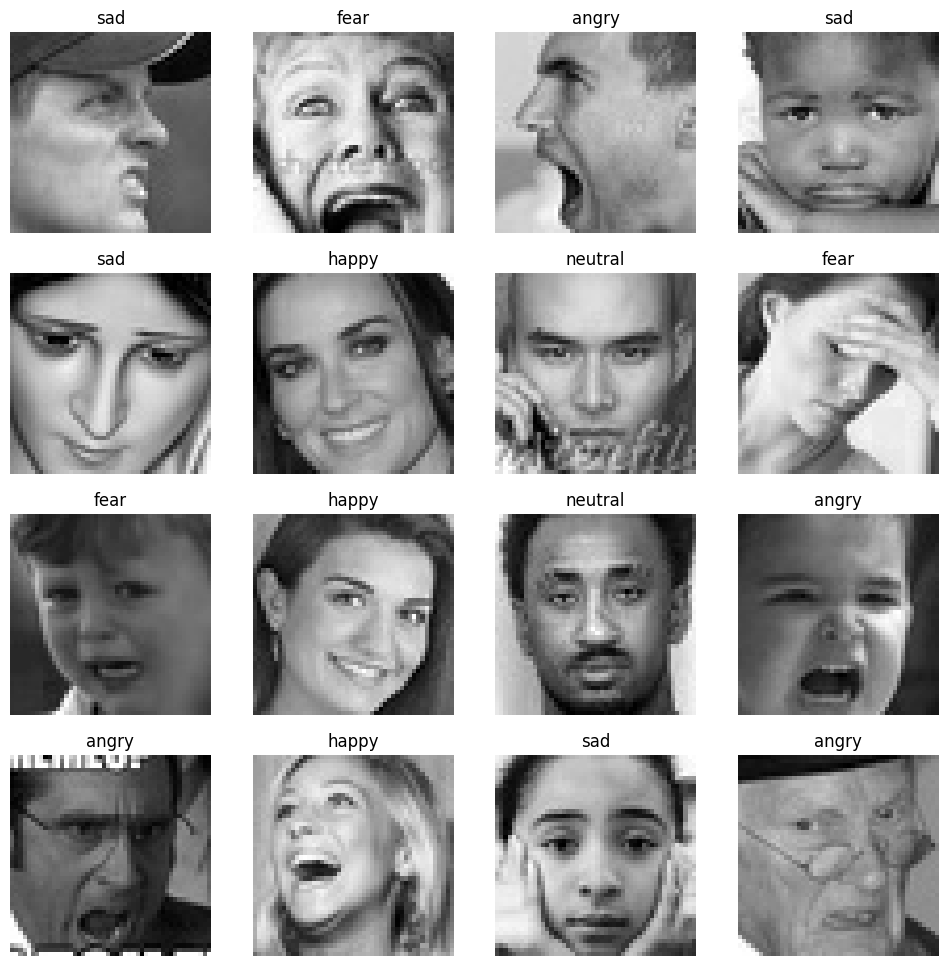

In [8]:

plt.figure(figsize=(12,12))

for images, labels in train_ds.take(1):

    for i in range(16):

        plt.subplot(4,4,i+1)

        plt.imshow(
            images[i].numpy().squeeze(),
            cmap="gray"
        )

        plt.title(class_names[labels[i]])

        plt.axis("off")

plt.show()

In [9]:

data_augmentation = keras.Sequential([

    layers.RandomFlip("horizontal"),

    layers.RandomRotation(0.1),

    layers.RandomZoom(0.1)

])

In [10]:

cnn_model = keras.Sequential([

    data_augmentation,

    layers.Rescaling(1./255),

    layers.Conv2D(32,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),

    layers.Dropout(0.5),

    layers.Dense(7,activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:

history_cnn = cnn_model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=30
)

Epoch 1/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 16s 19ms/step - accuracy: 0.2466 - loss: 1.8045 - val_accuracy: 0.3161 - val_loss: 1.7160
Epoch 2/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.2940 - loss: 1.7303 - val_accuracy: 0.3764 - val_loss: 1.6131
Epoch 3/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.3522 - loss: 1.6446 - val_accuracy: 0.4140 - val_loss: 1.5033
Epoch 4/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.3973 - loss: 1.5572 - val_accuracy: 0.4475 - val_loss: 1.4226
Epoch 5/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.4197 - loss: 1.5029 - val_accuracy: 0.4681 - val_loss: 1.3802
Epoch 6/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.4384 - loss: 1.4549 - val_accuracy: 0.4905 - val_loss: 1.3348
Epoch 7/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.4526 - loss: 1.4235 - val_accuracy: 0.4827 - val_loss: 1.3462
Epoch 8/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.4660 - loss: 1.3986 - val_acc

In [12]:

deep_cnn = keras.Sequential([

    data_augmentation,

    layers.Rescaling(1./255),

    layers.Conv2D(64,3,padding='same',activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(128,3,padding='same',activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(256,3,padding='same',activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.Conv2D(512,3,padding='same',activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    layers.GlobalAveragePooling2D(),

    layers.Dense(512,activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(256,activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(7,activation='softmax')
])

deep_cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

deep_cnn.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,949,447 (7.44 MB)

 Trainable params: 1,947,527 (7.43 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [13]:

history_deep = deep_cnn.fit(
    train_ds,
    validation_data=test_ds,
    epochs=30
)

Epoch 1/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 24s 42ms/step - accuracy: 0.2290 - loss: 1.8864 - val_accuracy: 0.2073 - val_loss: 1.8439
Epoch 2/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 18s 41ms/step - accuracy: 0.2889 - loss: 1.7371 - val_accuracy: 0.2920 - val_loss: 1.7067
Epoch 3/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.3619 - loss: 1.6032 - val_accuracy: 0.3948 - val_loss: 1.5420
Epoch 4/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 18s 41ms/step - accuracy: 0.4044 - loss: 1.5279 - val_accuracy: 0.4075 - val_loss: 1.5326
Epoch 5/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 18s 41ms/step - accuracy: 0.4306 - loss: 1.4762 - val_accuracy: 0.4908 - val_loss: 1.3317
Epoch 6/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 18s 40ms/step - accuracy: 0.4527 - loss: 1.4260 - val_accuracy: 0.4777 - val_loss: 1.3404
Epoch 7/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 18s 41ms/step - accuracy: 0.4607 - loss: 1.4011 - val_accuracy: 0.4739 - val_loss: 1.3571
Epoch 8/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 21s 42ms/step - accuracy: 0.4757 - loss: 1.3742 - 

In [14]:

def gray_to_rgb(image, label):

    image = tf.image.grayscale_to_rgb(image)

    return image, label

train_rgb = train_ds.map(gray_to_rgb)

test_rgb = test_ds.map(gray_to_rgb)

In [15]:

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(48,48,3)
)

base_model.trainable = False

mobilenet_model = keras.Sequential([

    layers.Rescaling(1./255),

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.5),

    layers.Dense(7,activation='softmax')
])

mobilenet_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

mobilenet_model.summary()

/tmp/ipykernel_4226/1093055289.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 2, 2, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [16]:

history_mobile = mobilenet_model.fit(
    train_rgb,
    validation_data=test_rgb,
    epochs=15
)

Epoch 1/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 46s 67ms/step - accuracy: 0.2811 - loss: 2.0002 - val_accuracy: 0.3661 - val_loss: 1.6256
Epoch 2/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.3357 - loss: 1.7133 - val_accuracy: 0.3714 - val_loss: 1.6028
Epoch 3/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.3447 - loss: 1.6780 - val_accuracy: 0.3778 - val_loss: 1.5958
Epoch 4/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.3516 - loss: 1.6698 - val_accuracy: 0.3791 - val_loss: 1.6038
Epoch 5/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.3515 - loss: 1.6624 - val_accuracy: 0.3824 - val_loss: 1.5996
Epoch 6/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.3530 - loss: 1.6621 - val_accuracy: 0.3780 - val_loss: 1.6003
Epoch 7/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.3535 - loss: 1.6611 - val_accuracy: 0.3812 - val_loss: 1.5923
Epoch 8/15
449/449 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.3544 - loss: 1.6551 - val_acc

CNN Accuracy: 55.475062131881714
Deep CNN Accuracy: 59.08331274986267
MobileNetV2 Accuracy: 38.4368896484375


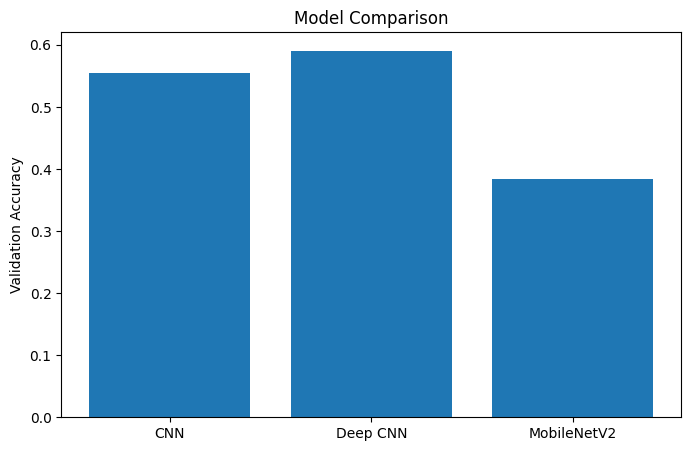

In [17]:

cnn_acc = max(history_cnn.history['val_accuracy'])
deep_acc = max(history_deep.history['val_accuracy'])
mobile_acc = max(history_mobile.history['val_accuracy'])

print("CNN Accuracy:", cnn_acc*100)
print("Deep CNN Accuracy:", deep_acc*100)
print("MobileNetV2 Accuracy:", mobile_acc*100)

plt.figure(figsize=(8,5))

plt.bar(
    ["CNN","Deep CNN","MobileNetV2"],
    [cnn_acc,deep_acc,mobile_acc]
)

plt.ylabel("Validation Accuracy")
plt.title("Model Comparison")

plt.show()

In [18]:

import pandas as pd

results = pd.DataFrame({
    "Model": ["CNN", "Deep CNN", "MobileNetV2"],
    "Validation Accuracy": [
        cnn_acc,
        deep_acc,
        mobile_acc
    ]
})

print(results)

         Model  Validation Accuracy
0          CNN             0.554751
1     Deep CNN             0.590833
2  MobileNetV2             0.384369


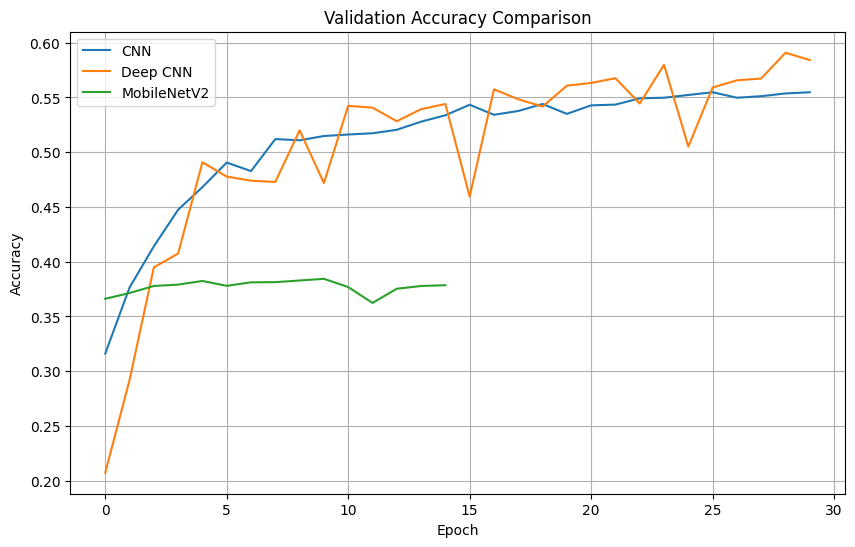

In [19]:

plt.figure(figsize=(10,6))

plt.plot(
    history_cnn.history['val_accuracy'],
    label='CNN'
)

plt.plot(
    history_deep.history['val_accuracy'],
    label='Deep CNN'
)

plt.plot(
    history_mobile.history['val_accuracy'],
    label='MobileNetV2'
)

plt.title("Validation Accuracy Comparison")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

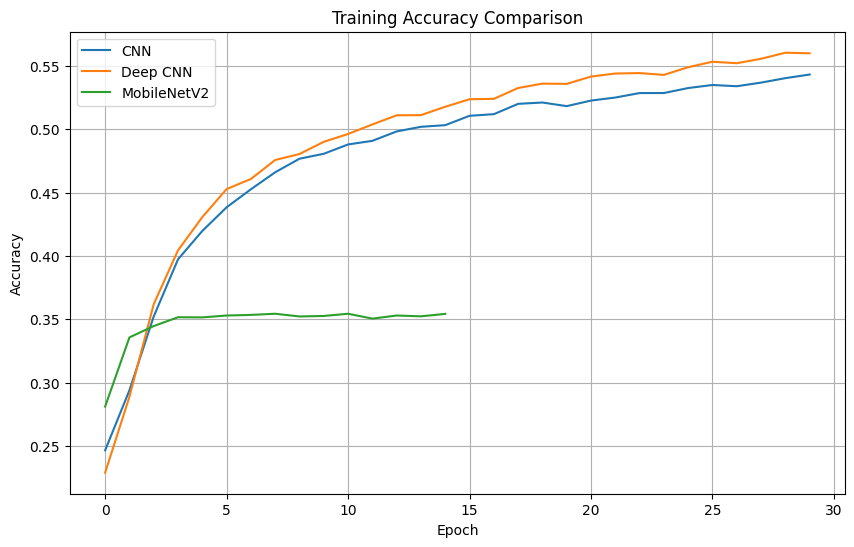

In [20]:

plt.figure(figsize=(10,6))

plt.plot(
    history_cnn.history['accuracy'],
    label='CNN'
)

plt.plot(
    history_deep.history['accuracy'],
    label='Deep CNN'
)

plt.plot(
    history_mobile.history['accuracy'],
    label='MobileNetV2'
)

plt.title("Training Accuracy Comparison")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend()

plt.grid(True)

plt.show()

In [21]:

uploaded = files.upload()

Saving OIP-886071635.jpg to OIP-886071635.jpg


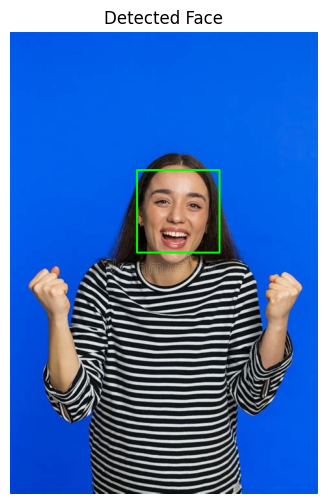

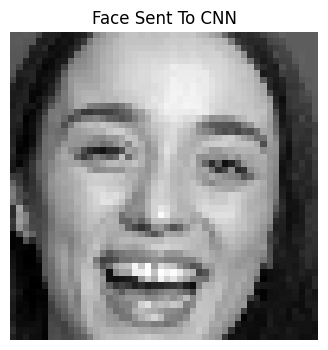

Input Shape: (1, 48, 48, 1)


In [22]:

image_path = list(uploaded.keys())[0]

img = cv2.imread(image_path)

img_rgb = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

gray = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2GRAY
)

face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades +
    "haarcascade_frontalface_default.xml"
)

faces = face_cascade.detectMultiScale(
    gray,
    scaleFactor=1.1,
    minNeighbors=5,
    minSize=(30,30)
)

if len(faces) == 0:

    print("❌ No Face Detected")

else:

    x, y, w, h = faces[0]

    cv2.rectangle(
        img_rgb,
        (x, y),
        (x+w, y+h),
        (0,255,0),
        2
    )

    face_gray = gray[y:y+h, x:x+w]

    face_gray = cv2.resize(
        face_gray,
        (48,48)
    )

    plt.figure(figsize=(6,6))
    plt.imshow(img_rgb)
    plt.title("Detected Face")
    plt.axis("off")
    plt.show()

    plt.figure(figsize=(4,4))
    plt.imshow(face_gray, cmap="gray")
    plt.title("Face Sent To CNN")
    plt.axis("off")
    plt.show()


    cnn_input = np.expand_dims(
        face_gray,
        axis=(0,-1)
    ).astype("float32")

    print("Input Shape:", cnn_input.shape)

In [23]:

cnn_prediction = cnn_model.predict(cnn_input)

cnn_class = np.argmax(cnn_prediction)

cnn_emotion = class_names[cnn_class]

cnn_confidence = np.max(cnn_prediction) * 100

print("CNN Prediction")
print("Emotion:", cnn_emotion)
print("Confidence:", f"{cnn_confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
CNN Prediction
Emotion: happy
Confidence: 79.42%


In [24]:
prediction = cnn_model.predict(cnn_input)

for emotion, prob in zip(class_names, prediction[0]):
    print(f"{emotion}: {prob*100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
angry: 1.38%
disgust: 0.07%
fear: 3.02%
happy: 79.42%
neutral: 0.23%
sad: 0.10%
surprise: 15.79%


In [25]:

deep_prediction = deep_cnn.predict(cnn_input)

deep_class = np.argmax(deep_prediction)

deep_emotion = class_names[deep_class]

deep_confidence = np.max(deep_prediction) * 100

print("\nDeep CNN Prediction")
print("Emotion:", deep_emotion)
print("Confidence:", f"{deep_confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step

Deep CNN Prediction
Emotion: happy
Confidence: 85.23%


In [26]:

mobile_face = cv2.cvtColor(
    face_gray.astype(np.float32),
    cv2.COLOR_GRAY2RGB
)

mobile_input = np.expand_dims(
    mobile_face,
    axis=0
)

mobile_prediction = mobilenet_model.predict(
    mobile_input
)

mobile_class = np.argmax(
    mobile_prediction
)

mobile_emotion = class_names[
    mobile_class
]

mobile_confidence = np.max(
    mobile_prediction
) * 100

print("\nMobileNetV2 Prediction")
print("Emotion:", mobile_emotion)
print("Confidence:", f"{mobile_confidence:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 12s 12s/step

MobileNetV2 Prediction
Emotion: happy
Confidence: 42.55%


In [27]:

print("\n")
print("="*50)
print("EMOTION PREDICTION COMPARISON")
print("="*50)

print(f"CNN          : {cnn_emotion:10s} {cnn_confidence:.2f}%")

print(f"Deep CNN     : {deep_emotion:10s} {deep_confidence:.2f}%")

print(f"MobileNetV2  : {mobile_emotion:10s} {mobile_confidence:.2f}%")



EMOTION PREDICTION COMPARISON
CNN          : happy      79.42%
Deep CNN     : happy      85.23%
MobileNetV2  : happy      42.55%


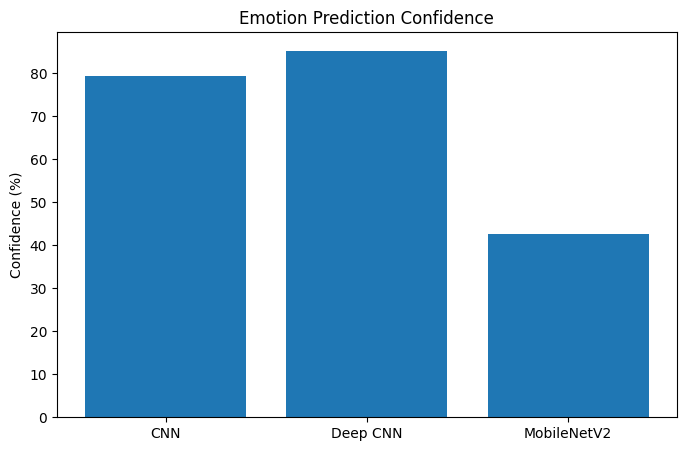

In [28]:

models = [
    "CNN",
    "Deep CNN",
    "MobileNetV2"
]

confidences = [
    cnn_confidence,
    deep_confidence,
    mobile_confidence
]

plt.figure(figsize=(8,5))

plt.bar(
    models,
    confidences
)

plt.ylabel("Confidence (%)")

plt.title(
    "Emotion Prediction Confidence"
)

plt.show()